In [1]:
# imports
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import geopandas as gpd

In [2]:
final_data = Path.cwd().parent.joinpath('processed_data', 'final_dataset.csv')

**Variables in final_dataset.csv**

- `geo_id`, `county_name`: unique ID of counties and names (names might be duplicated) 

- `population`: population of county in 2025 (released in March 2026 by Census)

- `median_household_income`: 

- `housing_units`: 

- `data_centers_count`: number of data centers in the county 

- `sfha_area`: severe flood hazard area (SFHA) in the county

- `pct_sfha`: proportion of the county that is SFHA

- `lake_count`: number of lakes that intersect the county

- `total_lake_area`: total lakes area in the county

- `avg_vol`: average volume of lakes in the county 

- `avg_depth`: average depth of lakes in the county 

- `avg_discharge`: average discharge of lakes in the county (discharge = the volume of water flowing out of it over a specific period)

- `dist_to_lakes_km`: distance from the county’s centroid to the nearest lake in kilometers

- `wetland_count`: number of wetlands that intersect the county

- `distance_to_rivers_km`: distance from the county’s centroid to the nearest river in kilometers

- `rivers_count`: number of rivers that intersect the county

- `total_rivers_mile`: total miles of rivers in the county

- `military_count`: number of military installations that intersects in the county

- `total_military_area_m`: total area of military installations in square meters

- `pct_military`: proportion of the county that are military installations 

- `plant_count`: number of operating nuclear plants in the county

- `pga_max`: peak ground acceleration (measure seismic risk)

- `distance_to_lines_km`: distance from the county’s centroid to the nearest transmission line in kilometers

- `transmission_lines_count`: number of transmission lines in the county

- `max_voltage`: maximum voltage of a transmission line in the county in kV

- `average_voltage`: average voltage of a transmission line in the county in kV

In [3]:
df = pd.read_csv(final_data)
df.head()

,Unnamed: 0,geo_id,county_name,population,median_household_income,housing_units,data_centers_count,sfha_area,pct_sfha,lake_count,...,total_rivers_mile,military_count,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage
0,0,40075,Kiowa County,"8,181",42679.0,4700.0,0.0,2.112674e+08,0.079146,10,...,688.07,0.0,0.000000e+00,0.000000,0.0,0.180,16.455467,10.0,138.0,110.400000
1,1,46079,Lake County,"10,993",74884.0,5714.0,0.0,1.890356e+08,0.126898,48,...,47.64,0.0,0.000000e+00,0.000000,0.0,0.051,2.165857,18.0,69.0,69.000000
2,2,37033,Caswell County,"22,563",56999.0,10493.0,0.0,6.618573e+07,0.059609,4,...,178.23,0.0,0.000000e+00,0.000000,0.0,0.082,10.562934,3.0,230.0,230.000000
3,3,48377,Presidio County,"5,433",29012.0,3396.0,0.0,0.000000e+00,0.000000,0,...,726.40,0.0,0.000000e+00,0.000000,0.0,0.150,6.887895,4.0,69.0,69.000000
4,4,39057,Greene County,"174,322",81243.0,71471.0,0.0,1.002618e+08,0.092999,8,...,276.85,1.0,2.104756e+07,0.019523,0.0,0.097,1.588568,44.0,345.0,112.909091


In [4]:
df.drop(columns='Unnamed: 0', inplace=True)

In [5]:
print(df.shape)
print(df.columns)

(3235, 27)
Index(['geo_id', 'county_name', 'population', 'median_household_income',
       'housing_units', 'data_centers_count', 'sfha_area', 'pct_sfha',
       'lake_count', 'total_lake_area', 'avg_vol', 'avg_depth',
       'avg_discharge', 'dist_to_lakes_km', 'wetland_count',
       'distance_to_rivers_km', 'rivers_count', 'total_rivers_mile',
       'military_count', 'total_military_area_m', 'pct_military',
       'plant_count', 'pga_max', 'distance_to_lines_km',
       'transmission_lines_count', 'max_voltage', 'average_voltage'],
      dtype='object')


In [6]:
df['population'] = df['population'].str.replace(',', '').astype(float)

In [7]:
df.dtypes

geo_id                        int64
county_name                  object
population                  float64
median_household_income     float64
housing_units               float64
data_centers_count          float64
sfha_area                   float64
pct_sfha                    float64
lake_count                    int64
total_lake_area             float64
avg_vol                     float64
avg_depth                   float64
avg_discharge               float64
dist_to_lakes_km            float64
wetland_count               float64
distance_to_rivers_km       float64
rivers_count                float64
total_rivers_mile           float64
military_count              float64
total_military_area_m       float64
pct_military                float64
plant_count                 float64
pga_max                     float64
distance_to_lines_km        float64
transmission_lines_count    float64
max_voltage                 float64
average_voltage             float64
dtype: object

In [8]:
df.isna().sum()

geo_id                       0
county_name                  0
population                  91
median_household_income     14
housing_units               13
data_centers_count           0
sfha_area                    0
pct_sfha                     0
lake_count                   0
total_lake_area              0
avg_vol                      0
avg_depth                    0
avg_discharge                0
dist_to_lakes_km             0
wetland_count                0
distance_to_rivers_km        0
rivers_count                 0
total_rivers_mile            0
military_count               0
total_military_area_m        0
pct_military                 0
plant_count                  0
pga_max                      0
distance_to_lines_km         0
transmission_lines_count     0
max_voltage                  0
average_voltage              0
dtype: int64

In [9]:
df.corr(numeric_only=True)

,geo_id,population,median_household_income,housing_units,data_centers_count,sfha_area,pct_sfha,lake_count,total_lake_area,avg_vol,...,total_rivers_mile,military_count,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage
geo_id,1.000000,-0.052978,-0.097271,-0.060522,0.019994,-0.163416,-0.144847,-0.089688,0.010002,0.040239,...,-0.103321,-0.074633,-0.046928,-0.047402,-0.011989,0.002421,0.106548,-0.087989,-0.058870,-0.029733
population,-0.052978,1.000000,0.293409,0.994368,0.278825,0.162070,0.067687,-0.007147,0.032434,0.034288,...,-0.011395,0.421579,0.144082,0.083143,0.080662,0.104364,-0.041346,0.667266,0.210232,0.083706
median_household_income,-0.097271,0.293409,1.000000,0.276719,0.207886,0.015680,-0.044384,0.020323,0.014571,0.013334,...,0.016085,0.195922,0.018792,0.036303,0.071194,-0.089715,-0.021744,0.234642,0.212872,0.132507
housing_units,-0.060522,0.994368,0.276719,1.000000,0.274372,0.164586,0.070456,-0.007057,0.043665,0.044062,...,-0.010441,0.417599,0.132200,0.078987,0.082006,0.082606,-0.047466,0.665322,0.211452,0.091089
data_centers_count,0.019994,0.278825,0.207886,0.274372,1.000000,0.028563,-0.001998,-0.004465,0.003371,0.002954,...,-0.002821,0.109776,0.049492,0.040923,0.028447,0.019792,-0.007222,0.178542,0.110805,0.079365
sfha_area,-0.163416,0.162070,0.015680,0.164586,0.028563,1.000000,0.715047,-0.001092,-0.000321,-0.015816,...,0.004457,0.145620,0.106044,0.067049,0.040794,0.010424,-0.039216,0.236249,0.124537,0.074093
pct_sfha,-0.144847,0.067687,-0.044384,0.070456,-0.001998,0.715047,1.000000,-0.036637,-0.064719,-0.041986,...,-0.042050,0.048455,-0.031416,0.043291,0.025387,0.059337,-0.059602,0.137113,0.107054,0.088881
lake_count,-0.089688,-0.007147,0.020323,-0.007057,-0.004465,-0.001092,-0.036637,1.000000,0.035402,-0.003582,...,0.826962,0.054937,-0.003153,-0.009738,-0.004614,0.022470,0.070649,-0.016549,-0.057759,-0.059384
total_lake_area,0.010002,0.032434,0.014571,0.043665,0.003371,-0.000321,-0.064719,0.035402,1.000000,0.599870,...,0.013116,-0.015819,-0.008027,-0.022038,0.054590,-0.093209,-0.007485,0.056621,-0.000322,-0.001024
avg_vol,0.040239,0.034288,0.013334,0.044062,0.002954,-0.015816,-0.041986,-0.003582,0.599870,1.000000,...,-0.011628,0.000067,-0.008525,-0.016369,0.026953,-0.059020,-0.005931,0.040032,0.013034,0.011366


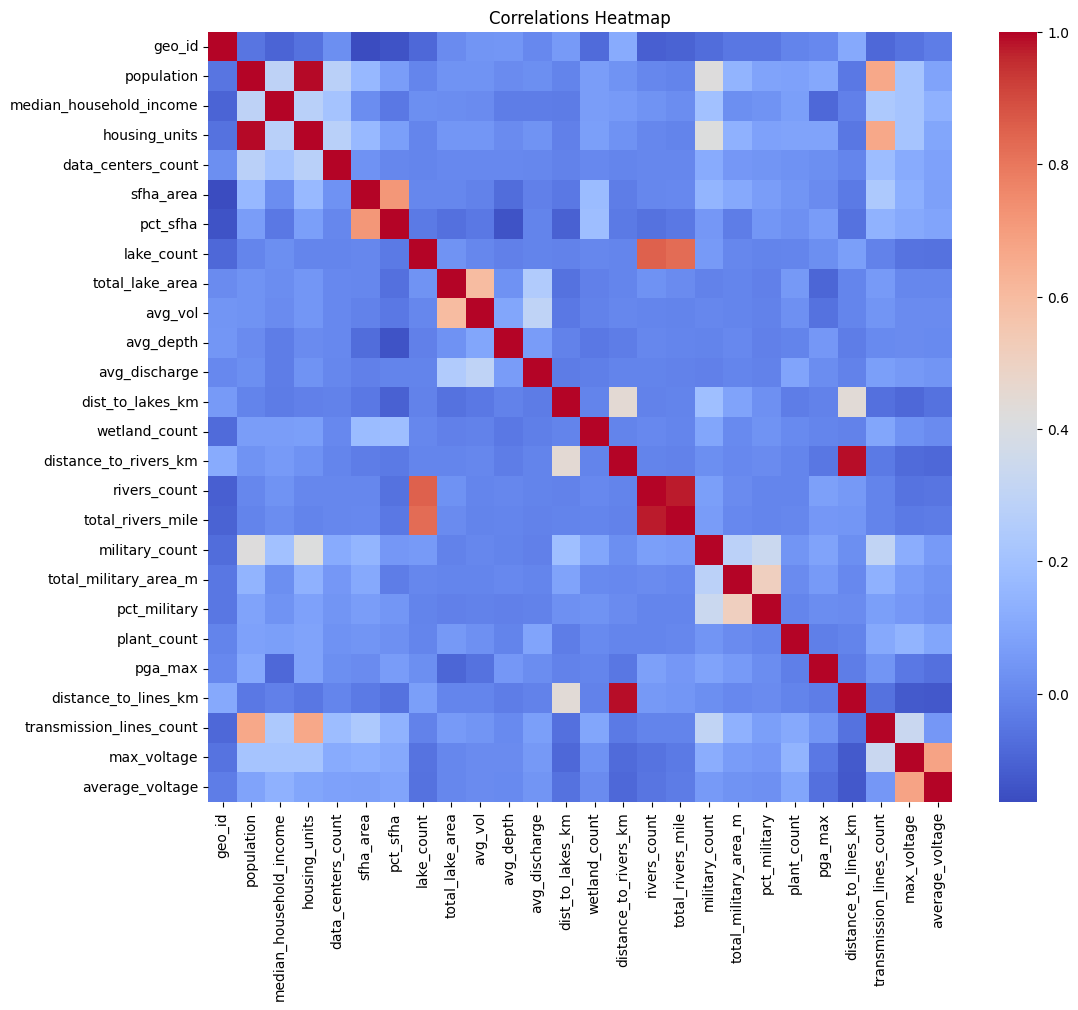

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(data=df.corr(numeric_only=True), cmap='coolwarm')
plt.title('Correlations Heatmap')
plt.show()

High correlation between `housing_units` and `median_household_income`,`distance_to_lines_km` and `distance_to_rivers_km`, and `total_rivers_mile` and `rivers_count`.

In [11]:
# sns.pairplot(df.drop(columns={'geo_id','county_name'}))

In [12]:
df[df['median_household_income'] <= 0]

,geo_id,county_name,population,median_household_income,housing_units,data_centers_count,sfha_area,pct_sfha,lake_count,total_lake_area,...,total_rivers_mile,military_count,total_military_area_m,pct_military,plant_count,pga_max,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage


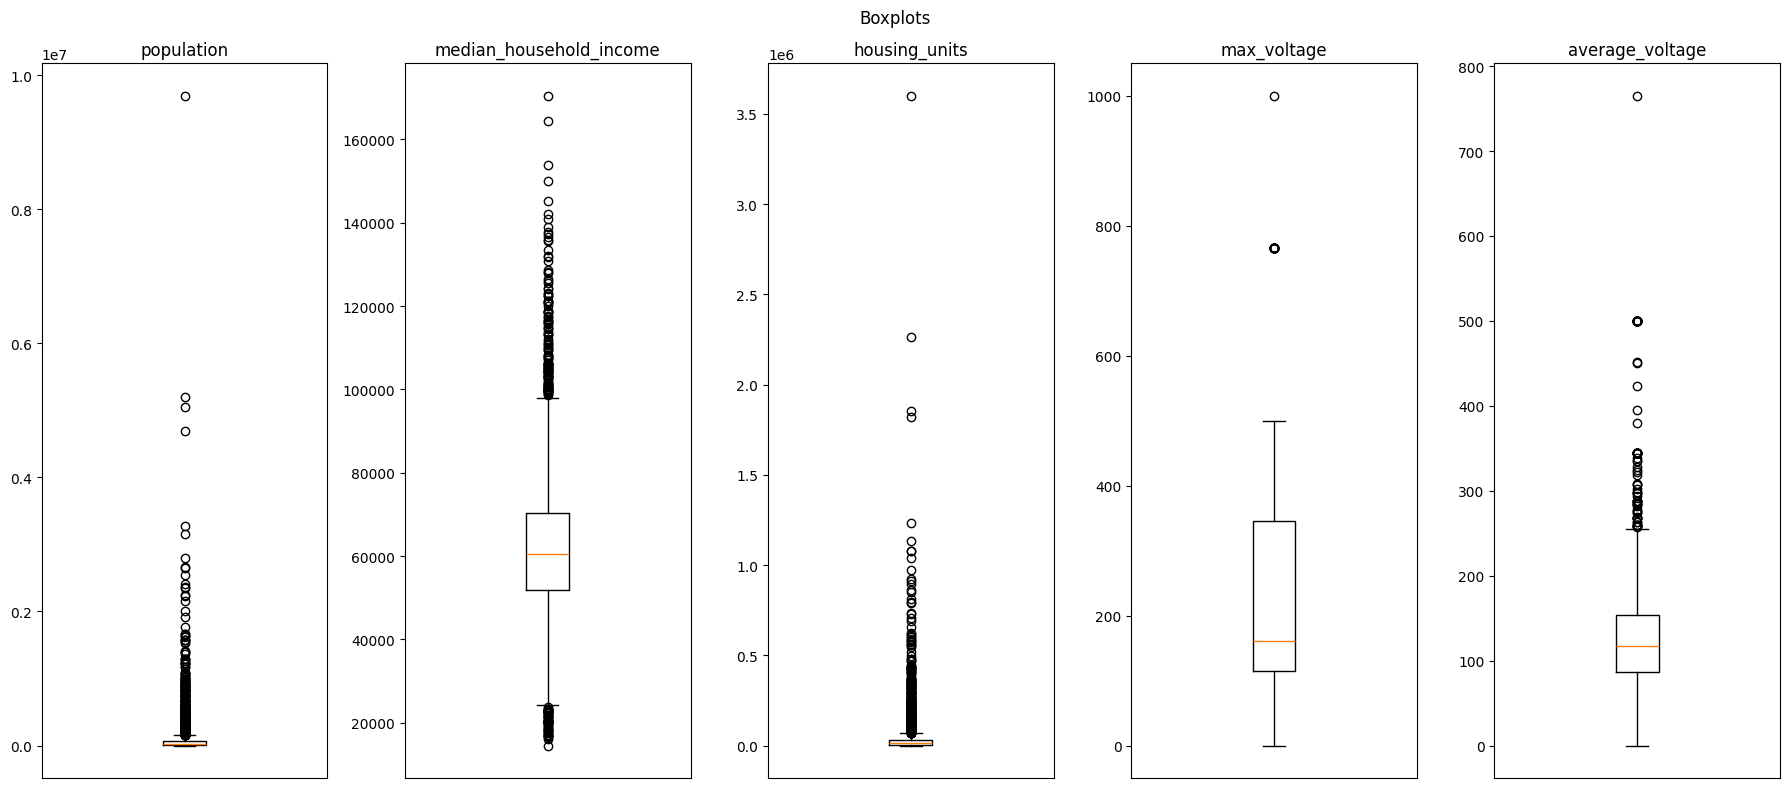

In [13]:
boxplot_cols = ['population', 'median_household_income', 'housing_units', 
                'max_voltage', 'average_voltage']
fig, axes = plt.subplots(1, len(boxplot_cols), figsize=(18,8))
axes = axes.flatten()

for i, col in enumerate(boxplot_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)
    axes[i].set_xticks([])   

plt.suptitle('Boxplots')
plt.tight_layout()
plt.show()

# will do more EDA soon tm